# Objetivo

O objetivo desta análise é identificar padrões que diferenciam transações fraudulentas de transações legítimas. A linguagem de programação utilizada foi `Python`, e a bibloteca utilizada para a visualização de dados foi `Pandas`, responsável por fornecer estruturas de dados essenciais para a análise, como o `dataframe`. A biblioteca para manipulação de números foi `Numpy` e `StandardScaler` para padronização e separação para teste e treino do modelo.

# Passo 1: Coleta de dados

Utilizando o `read.csv` do **Pandas**, os dados do **dataset** que contém informações de transações realizadas por cartões de crédito são carregados e o resultado é armazenado no **dataframe** `df`.

In [ ]:
import pandas as pd

url ="https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

# Visualização das 5 primeiras linhas do dataset
df.head()


Para a maior compreesão dos dados, podemos utilizar o `df.columns`, que lista todas as colunas do **dataset**.

In [ ]:
df.columns

Outra função que pode ser útil é a `df.info`, que informa a quantidade de colunas, tipo de dados, quantidade de valores nulos por coluna e o consumo de memória do **dataset**

In [ ]:
df.info()

O **dataset** contém várias colunas numéricas que representam caracteristicas das transações bancárias, além de uma coluna que indica se a transação é ou não fraudulenta.

Cada registro é uma operação feita por cartão de crédito. A coluna `Time` representa o momento da transação. Não se trata de uma data comum, mas uma váriavel númerica que indica o tempo desde o início até a coleta de dados.

A coluna `V1` até a `V28` são variáveis transformadas. Os dados originais foram processados utilizando técnicas de PCA para preservar a privacidade.

A penúltima coluna se chama `Amount` e representa o valor da transação. Essa variável é importante, porque as fraudes podem ter padrões específicos de valor.

A coluna `Class`, a última coluna da visualização, indica se a transação é ou não fraudulenta, sendo 0 indicando uma transação legítima, e 1 indicando uma fraude.

Para verificar como as classes estão distribuidas em números inteiros, podemos usar o método `value_counts`, que contabiliza quantas vezes cada valor aparece na coluna.

In [ ]:
df['Class'].value_counts()

Para calcular a proporção em porcentagem dos valores da coluna `Class`, podemos usar o `normalize=Tru`e.

In [ ]:
df['Class'].value_counts(normalize=True)

Como podemos ver, as transações legítimas representam 99,8% e apenas 0.17% são fraudes. Isso pode significar que o dataset está desbalanceado que é quando uma classe aparece mais que a outra. Isso pode fazer com que o modelo aprenda errado. Exemplo: O modelo pode responder sempre que não é fraude. Ele vai acertar a maioria das vezes, mas não conseguirá fazer o mais importante, que é detectar uma fraude.

# Passo 2: Modelagem de dados

## Feature Engineering

Agora, criaremos variaveis para ajudar o nosso modelo. A biblioteca numpy, ajuda a realizar operações matemáticas, entre outrras coisas, nos ajudará com essa etapa.

In [ ]:
import numpy as np
df['Amount_log'] = np.log1p(df['Amount'])

`df['Amout_log] = np.log1p(df['Amount']) `aplica uma transformação logarítimica nos valores da columa `Amount`. Isso evita problemas com valores igual a `0`, já que o log 0 não vai existir. Isso porque em dados financeiros, como valores de transações, é normal ter valores muito diferentes em si, e isso pode dificultar o aprendizado do modelo.

## Padronização dos dados

Aqui, usaremos a ferramenta sklearn, da biblioteca Standard Scaler. Ela transformará os dados para que tenham a média igual a `0` e desvio padrão igual a `1`, para que os valores fiquem na mesma escala, independente tamanho original. Dessa forma valores muito grandes ou muito pequenos passam a ser comparaveis. O resultado será armazedo em outra coluna chamada `Amount_scaled`.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

## Preparação dos dados para testes e treinamento do modelo

Separamos as variaveis em `x` e `y`. O `x` representa as variaveis de entrada e o` y` representa o alvo (`'Class'`). Assim, a coluna `Class` irá indicar se a transação é um fraude ou não.

O `train_test_split `separa os dados em conjuntos de **treino** e **teste**. O conjunto de treino é utilizado para ensinar o modelo, e o conjunto de teste avalia o modelo posteriormente.

O `test_size=0.3` representa 30% dos dados que vão para teste, e os outros 70% irão para treino. O `random_state=42 `garante que a divisão seja a mesma. O `stratify=y `garante que a proporção de fraudes e não fraudes seja mantida para ambos os conjuntos.

In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop(['Class'], axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

# Passo 3: Avaliação do modelo
## Regressão Logística

O **Logistic Regression** é um modelo de classificação, que é usado para prever categorias. No nosso caso queremos prever se a transação é fraude ou não. Esse modelo será usado como baseline, ou seja, servirá de referência para que outros modelos posteriores funcionem corretamente.

O parametro `max-iter `define o número de interações. O `model_fit` é usado para que o modelo aprenda padrões a partir dos dados de treino. Ele tenta encontrar relações entre as variaveis, features e o resultado, fraude ou não fraude. O` model_predict `é usado para fazer previsões com os dados de teste.

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ao rodar o código, recebemos um warning, porque o modelo não conseguiu terminar o número de interações definidos. Vamos continuar mesmo assim.

Para ver como o modelo se saiu, podemos utilizar o classification_report, que permite que vejamos as métricas mais importantes da nossa avaliação.

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



O `precision` ficou em **0.87**, o que significaria que o modelo classificou 87% como fraudes.

O `recall` ficou em **0.68**, o que significaria que o modelo classificou **68%** como fraudes reais. Isso significa que o modelo estaria deixando passar cerca de **32%** de fraudes reais.

O `f1-score` ficou em **0.77**. o que significaria que **77%**, que seria uma média harmonica entre **precisão** e **recall**, seriam classificadas como fraudes. Essa classe atua como uma visão geral do modelo.

A **accuracy** ficou em **1.00**, ou seja 100%. A acuracia tão alta muitas vezes é um mau sinal. Contexto do nosso problema, pode significar que, pelo fato do dataset ser desbalanceado, acuracia pode estar viciada, prevendo a classe zero.

No nosso contexto, a classe mais importante para a analise é a classe `recall`.

## ROC Curve

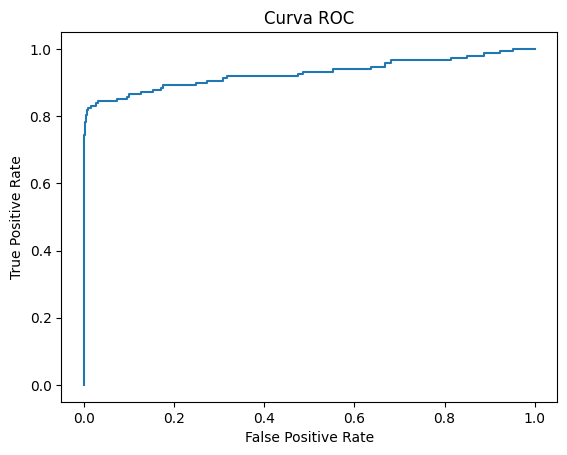

AUC: 0.9272042339543365


In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

print('AUC:', roc_auc_score(y_test, y_probs))

Também podemos utilizar a curva roc para está analise. Essa métrica é muito importante para modelos de classificação. Esse gráfico nos mostra o desempenho do modelo eem diferentes lineares de decisão.

No eixo horizontal temos o **False Positive Rate**, que representa a taxa de falsos positivos, ou seja quantas transações legítimas foram classificadas como fraude. No eixo vertical temos o **True Position Rate** que representa o mesmo que o **recall**, ou seja fraudes reais o modelo realmente conseguiu identificar. Cada ponto da curva vai representar um limite diferente da decisão do modelo. Ao invés de se fixar em um único limite, podemos analisar o comportamento geral. Quanto mais a curva se aproxima do canto esquerdo, melhor é o modelo. Isso porquê isso significa alto **recall** e baixo erro.

Se a curva fosse uma linha reta diagonal, o modelo seria aleatório, ou seja, não teria capacidade de distinguir fraude e não fraude.

A área sobre a curva foi de aproximadamente 93 (92.8). Um valor próximo de 1 indica que o modelo está muito bom. Um valor próximo de 0.5 indica dados aleatórios. Isso significa que nosso modelo tem boa capacidade de separar fraudes de transações legítimas.

## Precision-Recall Curve

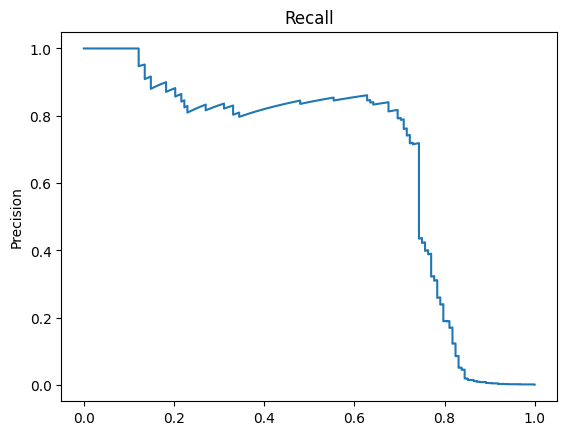

In [37]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.title('Recall')
plt.ylabel('Precision')
plt.show()

Essa metrica é ainda mais importante em problemas de fraudes desbalanceadas.

No eixo horizontal, temos o **recall**, ou seja, quantas fraudes o modelo consegue indentificar e no eixo vertical temos o **precision**, ou seja, entre as transações como fraude, quantas realmente são fraude.

Esse gráfico mostra o equilíbrio entre essas duas métricas. Quando tentamos aumentar o **recall**, o **precision** diminui e vice-versa.

Quando o **precision** está muito alto, ele só aponta fraudes quando tem muita certeza e o **recall** é baixo, o que significa que muitas fraudes passam despercebidas.

Quando o **recall** está muito alto, o modelo passa a identificar mais fraudes, porém o **precision** cai, e aumentam os falsos positivos.

## Balanceamento de dados


In [38]:
## Undersampling

fraudes = df[df['Class'] == 1]
legitimas = df[df['Class'] == 0].sample(n=len(fraudes), random_state=42)

df_balanced = pd.concat([fraudes, legitimas])

Quando o objetivo é criar um dataset equilibrado, com a mesma quantidade de fraudes e não fraudes, podemos utilizar o `undersampling`.

Aqui, pegamos todas as fraudes e depois seleciona a mesma quantidade de transações usando o sample. Ou seja, reduzimos a classe majoritária (classe 0), para ficar do mesmo tamanho da classe minoritária (classe 1) e por fim, junta tudo.

O modelo aprende a indentificar fraudes, mas acaba perdendo muitos dados, então podem reduzir a qualidade dos dados.

In [39]:
## Oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_resampled, y_resampled = smote.fit_resample(x, y)

No oversampling, são criados novos exemplos sintéticos da classe minoritária. O ponto positivo dessa solução é são se perde dados e se aumenta a representação da classe fraude. Por outro lado, os dados criados são artificiais, então pode incluir ruído.

A única forma se saber qual seria a melhor forma de balancear os dados é testando.

## Random Forest Classifier

Outro modelo de classificação é **Random Forest Classifier**, baseado em árvores de decisão. Nele existe um conjunto de várias árvores de decisão. Cada árvore vai aprender um padrão diferente dos dados e no final o modelo combina as decisões.

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
	n_estimators=50,
	max_depth=10,
	class_weight='balanced',
	n_jobs=-1,
	random_state=42,
 )

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



O `number_estimators=50` significa que estão sendo escolhidas 50 árvores. O `max_depth=10` significa que a profundidade utilizada está limitada a 10 árvores, para evitar overfitting. Ou seja, quando o modelo decora o dados de treino e não consegue classificar os novos dados na hora do teste. O `class_weight` setando `'balanced'` ajusta automaticamente o peso da classes, dando mais importância para a classe minoritária, que são as fraudes. Isso ajuda o modelo a não ignorar essas ocorrências que tendem a ser mais raras. O resultado foi o seguinte> o **recall** (indentificação dos fraudes) foi de 76% das fraudes. Temos uma melhora na capacidade do modelo detectar fraudes em relação a **regressão logística**. O **f1_score** também aumentou, e agora está em 79%.

## Pipeline de teste

Aqui aplicaremos duas ideias importantes em projetos de **machine learning**, que é o **pipeline** e o ajuste de **threshold**.

O pipeline serve para organizar o fluxo de processamento. Nesse pipeline específico, utilizamos o `StandarScaler` e o `LogisticRegression`, e dessa forma os dados passam automaticamente pela padronização, depois pelo modelo, tudo em um único fluxo. Isso ajuda a evitar e erros e garante mais consistência. Em projetos reais, o mesmo processamento pode ser aplicado tanto no treino, como no teste em produção.

Por padrão o modelo usa um threshold de 0.5, ou seja, se a probabilidade de fraude for maior que 0.5, ele classifica como fraude. Nesse projeto, o threshold foi ajustado para 0.3, para que o recall seja mais alto, na tentativa de detectar mais fraudes, mesmo que isso cause mais falsos positivos

In [52]:
import shap
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
	('scaler', StandardScaler()),
	('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [42]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.71      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



## Modelo avançado - XGBoost

O **XGBoost** é um dos algoritmos mais usados em competições e projetos reais de mercado, como em detecções de fraude, acidentes e anomalias.

Esse algoritmo é baseado em `boosting`, que é uma técnica onde vários modelos simples, geralmente árvores, são treinados em sequência e cada novo modelo tenta corrigir os erros anteriores. Diferente do **Random Forest**, onde as árvores são independentes, no XGBoost existe um aprendizado sequencial, e isso torna o modelo mais poderoso ainda.

In [43]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
	scale_pos_weight=10, # ajuda com o desbalanceamento
	use_label_encoder=False,
	eval_metric='logloss'
)

xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [22:37:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [44]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



Com ele, a **precission** ficou em 93% de acerto de que se é ou não fraude. O recall ficou em 78%.


# Passo 4: Finalização

## Importância das variáveis

O gráfico abaixo ajuda a entender quais variáveis influenciam mais o modelo. No eixo horizontal, temos as variáveis de V1 até V28, além de outras como o Amount. No eixo vertical, temos a importância de cada variável no modelo. Do ponto de vista de análise de dados, o gráfico ajuda a interpretar o modelo, entender quais fatores estão influenciando na decisão, além de ajudar na seleção de variáveis, para focar nas mais importantes para a análise ou até remover variáveis não relevantes. O gráfico também ajuda no entendimento do negócio, porque com ele é possível investigar o que essas variáveis representam e como elas se relacionam com as fraudes.

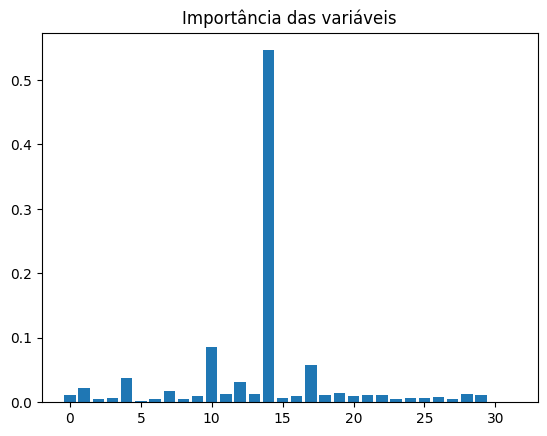

In [46]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title('Importância das variáveis')
plt.show()

## Ajuste de hiperparâmetros

O ajuste de hiperparâmetros
testa combinações para melhorar o modelo. Aqui utilizamos um `GridSearchCV`, que é uma técnica para testar automaticamente várias combinações de parâmetros.

In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
	'n_estimators': [50, 100, 200],
	'max_depth': [3, 5, 10, 20, 50],
}

grid_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    scoring='recall',
 cv=3
)

grid_search.fit(x_train, y_train)

print('Melhor modelo:', grid_search.best_params_)

Melhor modelo: {'max_depth': 10, 'n_estimators': 200}


Em **machine learning**, o modelo tem configurações de hiperparâmetro, e esses parâmetros não são aprendidos pelo modelo, mas eles precisam ser definidos pelo analista. O `param_grid` é o conjunto de combinações para teste.  O grid treina vários modelos, cada um com uma combinação diferente de parâmetros e avalia qual é o melhor.

## Explicabilidade (SHAP)

O **SHAP** mostra como cada variável influencia a decisão do modelo.



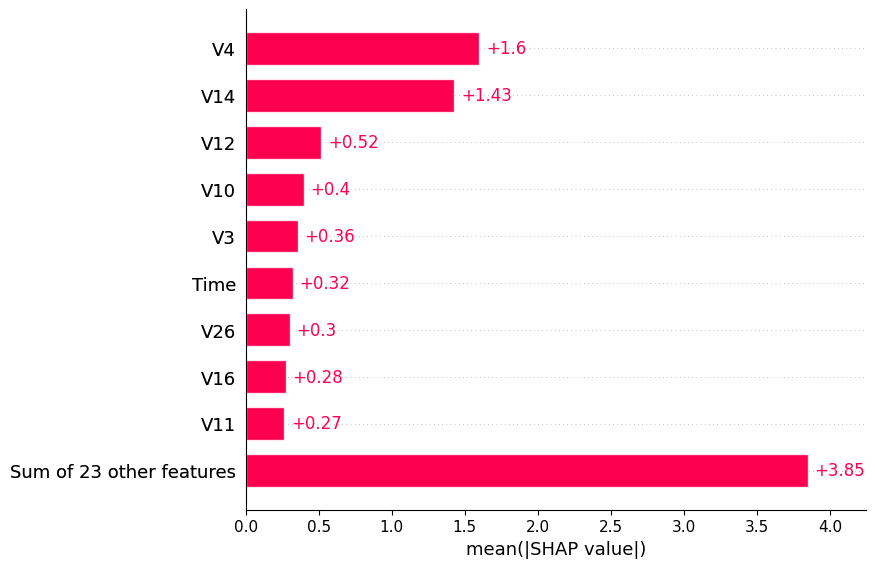

In [51]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)

O ponto mais importante é que o sharp nos permite entender o modelo mesmo se ele for complexo. Em áreas como fraude, onde é necessário justificar essas decisões, com essa ferramenta é possível descobrir o porquê uma determinada transação foi marcada como fraude, analisando quais variáveis levaram a essa decisão. Saber mapear essas informações é importante para a Cibersegurança, confiança, auditoria e uso em produção.
